In [2]:
import json
import os

QG_DIR = os.path.join("..", "..", "Outputs", "qg")
OUTPUT_DIR = os.path.join("..", "..", "Outputs", "analysis")
DATASETS = ["CaseReportBench", "DiscourseEE", "MACCROBAT", "PHEE"]
MODEL_TAG = "gpt-oss-120b-zs-v0"
SPLIT = "dev"

os.makedirs(OUTPUT_DIR, exist_ok=True)


def load_json(path):
    with open(path) as f:
        return json.load(f)


def build_lookup(records, key_fields=("serial-number", "role")):
    """Index records by (serial-number, role) for O(1) matching."""
    return {tuple(rec[k] for k in key_fields): rec for rec in records}


def consolidate_dataset(dataset):
    """
    Load the three dev-split QG files and merge on (serial-number, role):
      - schema-qg-*           → vanilaQ   (generic role-level)
      - loqa-qg-*             → zs-LoQ    (context-aware, zero-shot)
      - optimized_loqa-qg-*   → opt-LoQ   (optimized loqa)
    """
    qg_path = os.path.join(QG_DIR, dataset)

    schema_file = os.path.join(qg_path, f"schema-qg-{dataset}-{SPLIT}-{MODEL_TAG}.json")
    loqa_file   = os.path.join(qg_path, f"loqa-qg-{dataset}-{SPLIT}-{MODEL_TAG}.json")
    opt_file    = os.path.join(qg_path, f"optimized_loqa-qg-{dataset}-{SPLIT}-{MODEL_TAG}.json")

    for fp in [schema_file, loqa_file, opt_file]:
        if not os.path.exists(fp):
            print(f"  [SKIP] Missing: {fp}")
            return None

    schema_data = load_json(schema_file)
    loqa_data   = load_json(loqa_file)
    opt_data    = load_json(opt_file)

    print(f"  vanilaQ: {len(schema_data)} | zs-LoQ: {len(loqa_data)} | opt-LoQ: {len(opt_data)}")

    loqa_lookup = build_lookup(loqa_data)
    opt_lookup  = build_lookup(opt_data)

    consolidated = []
    matched = 0
    for rec in schema_data:
        key = (rec["serial-number"], rec["role"])

        entry = {k: v for k, v in rec.items() if k != "schema_questions"}
        schema_q = rec.get("schema_questions", "")
        entry["vanilaQ"] = [schema_q] if isinstance(schema_q, str) else schema_q

        loqa_rec = loqa_lookup.get(key)
        if loqa_rec:
            lq = loqa_rec.get("loqa_questions", [])
            entry["zs-LoQ"] = lq if isinstance(lq, list) else [lq]
        else:
            entry["zs-LoQ"] = []

        opt_rec = opt_lookup.get(key)
        if opt_rec:
            oq = opt_rec.get("optimized_loqa_questions", [])
            entry["opt-LoQ"] = oq if isinstance(oq, list) else [oq]
        else:
            entry["opt-LoQ"] = []

        if loqa_rec and opt_rec:
            matched += 1
        consolidated.append(entry)

    print(f"  Total: {len(consolidated)} | Fully matched: {matched}")
    return consolidated


# --- Run consolidation and save single combined file ---
all_records = []

for dataset in DATASETS:
    print(f"\n{'='*60}")
    print(f"Processing: {dataset}")
    print(f"{'='*60}")

    result = consolidate_dataset(dataset)
    if result is None:
        continue

    for rec in result:
        rec["dataset"] = dataset
    all_records.extend(result)

    sample = result[0]
    print(f"\n  Sample (first record):")
    print(f"    dataset:       {sample['dataset']}")
    print(f"    serial-number: {sample['serial-number']}")
    print(f"    role:          {sample['role']}")
    print(f"    vanilaQ:       {sample['vanilaQ']}")
    print(f"    zs-LoQ:        {sample['zs-LoQ']}")
    print(f"    opt-LoQ:       {sample['opt-LoQ']}")

# Save per-dataset files
for dataset in DATASETS:
    ds_records = [r for r in all_records if r["dataset"] == dataset]
    ds_path = os.path.join(OUTPUT_DIR, f"{dataset}-dev-questions-consolidated.json")
    with open(ds_path, "w") as f:
        json.dump(ds_records, f, indent=2, ensure_ascii=False)
    print(f"  {dataset}: {len(ds_records)} records → {os.path.basename(ds_path)}")

# Save combined file
out_path = os.path.join(OUTPUT_DIR, "all-dev-questions-consolidated.json")
with open(out_path, "w") as f:
    json.dump(all_records, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"Combined file: {os.path.abspath(out_path)}")
print(f"Total records: {len(all_records)}")
print(f"{'='*60}")


Processing: CaseReportBench
  vanilaQ: 350 | zs-LoQ: 350 | opt-LoQ: 350
  Total: 350 | Fully matched: 350

  Sample (first record):
    dataset:       CaseReportBench
    serial-number: dev-1
    role:          Pregnancy
    vanilaQ:       ['Is there any information indicating pregnancy status, history, or related complications?']
    zs-LoQ:        ["What were the details of the patient's delivery, specifically gestational term, birth weight, and birth height?"]
    opt-LoQ:       ["Describe the details of the patient's delivery and any notable perinatal outcomes."]

Processing: DiscourseEE
  vanilaQ: 500 | zs-LoQ: 500 | opt-LoQ: 500
  Total: 500 | Fully matched: 500

  Sample (first record):
    dataset:       DiscourseEE
    serial-number: dev-1
    role:          intervention
    vanilaQ:       ['What measures are taken to address or reduce side effects?']
    zs-LoQ:        []
    opt-LoQ:       []

Processing: MACCROBAT
  vanilaQ: 500 | zs-LoQ: 500 | opt-LoQ: 500
  Total: 500 | 

## Optimized question analysis

In [51]:
import os
import sys
import argparse
import wandb

# Ensure repository root is on sys.path so "Code" is importable
REPO_ROOT = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from Code.src.utils.io import read_json_file, save_json_file

## Loading the LoQA outputs
output_path = "/dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/"
eval_dict = {}
dataset_names = ["CaseReportBench", "PHEE", "DiscourseEE", "MACCROBAT"]
for dataset_name in dataset_names:
    file_name = f"optimized_loqa-{dataset_name}-dev-gpt-oss-120b-zs-v0.json"
    file_path = os.path.join(output_path, dataset_name, file_name)
    if os.path.exists(file_path):
        print(f"File exists: {file_path}")
    else:
        print(f"File does not exist: {file_path}")

    predictions = read_json_file(file_path)
    eval_dict[dataset_name] = predictions

File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/CaseReportBench/optimized_loqa-CaseReportBench-dev-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/CaseReportBench/optimized_loqa-CaseReportBench-dev-gpt-oss-120b-zs-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-dev-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/PHEE/optimized_loqa-PHEE-dev-gpt-oss-120b-zs-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-dev-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/DiscourseEE/optimized_loqa-DiscourseEE-dev-gpt-oss-120b-zs-v0.json
File exists: /dartfs-hpc/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/qo/MACCROBAT/optimized_loqa-MACCROBAT-dev-gpt-oss-120b-zs-v0.json
Reading JSON file from: /dartfs-hpc/rc

In [52]:
dataset_names = list(eval_dict.keys())
for dataset_name in dataset_names:
    print(dataset_name)
    print(len(eval_dict[dataset_name]))
    print(eval_dict[dataset_name][0])
    eval_data = eval_dict[dataset_name]
    for pred in eval_data:
        print(pred['best_iteration_number'])
        break

CaseReportBench
350
{'serial-number': 'dev-1', 'pmcid': '9718918', 'text': "{'CASE PRESENTATION': 'A 31‐year‐old mentally disabled man was referred to our neurologic clinic with a gradually worsening gait disorder, impaired balance, and repeated falling episodes. The patient was the third child of consanguinity marriage. He was delivered following a normal term pregnancy with normal birthweight and height. History of atheromatous disease or intractable infantile‐onset diarrhea was not distinguished. At the age of five, he developed a blurred vision, which was diagnosed as a bilateral cataract. The patient was a school dropout due to intellectual and neuropsychiatric disability. He had developmental delays in the mental functioning and speech with a normal physical growth. At the age of 20, he developed bilateral tendinous swelling of the posterior part of the ankles that worsened over time. He complained of severe gait disturbance and ataxia since 3–4 years ago. He had frequent falling

## Distribution of best questions

In [53]:
from collections import Counter

# Create buckets for each dataset showing count of items by best_iteration_number
iteration_buckets = {}

for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    
    # Count how many items have each best_iteration_number
    iteration_counts = Counter()
    for pred in eval_data:
        iter_num = pred.get('best_iteration_number', 0)
        iteration_counts[iter_num] += 1
    
    iteration_buckets[dataset_name] = dict(sorted(iteration_counts.items()))
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total items: {len(eval_data)}")
    print(f"\nBest Iteration Number Distribution:")
    for iter_num in sorted(iteration_counts.keys()):
        count = iteration_counts[iter_num]
        percentage = (count / len(eval_data)) * 100
        print(f"  Iteration {iter_num}: {count:5d} items ({percentage:5.2f}%)")
    print()

# Store buckets for later use
print("\nBuckets dictionary:")
print(iteration_buckets)


Dataset: CaseReportBench
Total items: 350

Best Iteration Number Distribution:
  Iteration 0:   266 items (76.00%)
  Iteration 1:    54 items (15.43%)
  Iteration 2:    24 items ( 6.86%)
  Iteration 3:     3 items ( 0.86%)
  Iteration 4:     3 items ( 0.86%)


Dataset: PHEE
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   432 items (86.40%)
  Iteration 1:    44 items ( 8.80%)
  Iteration 2:    19 items ( 3.80%)
  Iteration 3:     3 items ( 0.60%)
  Iteration 4:     2 items ( 0.40%)


Dataset: DiscourseEE
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   267 items (53.40%)
  Iteration 1:   119 items (23.80%)
  Iteration 2:    68 items (13.60%)
  Iteration 3:    35 items ( 7.00%)
  Iteration 4:    11 items ( 2.20%)


Dataset: MACCROBAT
Total items: 500

Best Iteration Number Distribution:
  Iteration 0:   372 items (74.40%)
  Iteration 1:    66 items (13.20%)
  Iteration 2:    33 items ( 6.60%)
  Iteration 3:    29 items ( 5.80%)


Buckets dict

Saved: ../../Code/xDev/best_iteration_distribution.png


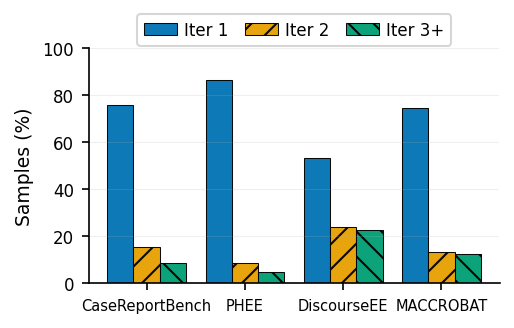

In [61]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

ITER_COLORS = {
    0: "#0072B2",
    1: "#E69F00",
    2: "#009E73",
}
ITER_HATCHES = {
    0: "",
    1: "//",
    2: "\\\\",
}
ITER_LABELS = {
    0: "Iter 1",
    1: "Iter 2",
    2: "Iter 3+",
}

datasets = list(iteration_buckets.keys())

# Merge iter 2,3,4,... into a single "3+" bucket
merged_buckets = {}
for ds in datasets:
    merged = {}
    for it, cnt in iteration_buckets[ds].items():
        key = min(it, 2)  # 0→0, 1→1, 2+→2
        merged[key] = merged.get(key, 0) + cnt
    merged_buckets[ds] = merged

bucket_ids = [0, 1, 2]

pct_matrix = []
for bid in bucket_ids:
    row = []
    for ds in datasets:
        total = sum(merged_buckets[ds].values())
        row.append(merged_buckets[ds].get(bid, 0) / total * 100)
    pct_matrix.append(row)

fig, ax = plt.subplots(figsize=(3.5, 2.6))

x = np.arange(len(datasets))
width = 0.8 / len(bucket_ids)

for i, bid in enumerate(bucket_ids):
    offset = (i - len(bucket_ids) / 2 + 0.5) * width
    vals = pct_matrix[i]

    ax.bar(
        x + offset, vals, width,
        label=ITER_LABELS[bid],
        color=ITER_COLORS[bid],
        edgecolor="black", linewidth=0.5,
        hatch=ITER_HATCHES[bid],
        alpha=0.95,
    )

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=7)
ax.set_ylabel("Samples (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.18),
    ncol=len(bucket_ids), frameon=True,
    columnspacing=1.0, handletextpad=0.4,
)

SAVE_PATH = os.path.join("..", "..", "Code", "xDev", "best_iteration_distribution.png")
plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(SAVE_PATH, bbox_inches="tight")
print(f"Saved: {SAVE_PATH}")
plt.show()



Dataset: CaseReportBench
Samples with questions: 350 / 350
  1 question(s):   143 samples (40.86%)
  2 question(s):    63 samples (18.00%)
  3 question(s):    49 samples (14.00%)
  4+ question(s):    95 samples (27.14%)

Dataset: PHEE
Samples with questions: 500 / 500
  1 question(s):   424 samples (84.80%)
  2 question(s):    60 samples (12.00%)
  3 question(s):    13 samples ( 2.60%)
  4+ question(s):     3 samples ( 0.60%)

Dataset: DiscourseEE
Samples with questions: 498 / 500
  1 question(s):   295 samples (59.24%)
  2 question(s):    98 samples (19.68%)
  3 question(s):    58 samples (11.65%)
  4+ question(s):    47 samples ( 9.44%)

Dataset: MACCROBAT
Samples with questions: 500 / 500
  1 question(s):   431 samples (86.20%)
  2 question(s):    63 samples (12.60%)
  3 question(s):     6 samples ( 1.20%)
Saved: ../../Code/xDev/question_count_distribution.png


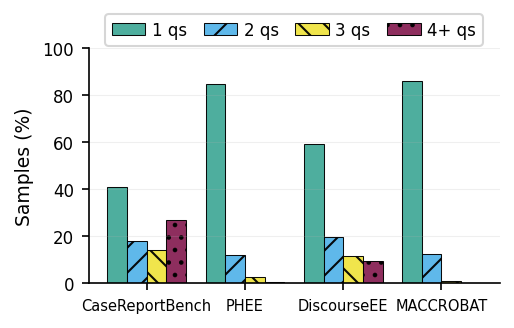

In [62]:
# How many questions in the final best? Bucket: samples with 1, 2, 3, 4+ questions
from collections import Counter

question_count_buckets = {}
for dataset_name in dataset_names:
    eval_data = eval_dict[dataset_name]
    counts = Counter()
    for pred in eval_data:
        bt = pred.get('best_trace')
        qs = (bt.get('loqa_questions') if bt else None) or pred.get('optimized_loqa_questions') or []
        n = len(qs) if isinstance(qs, list) else 0
        if n == 0:
            continue
        n_bucket = min(n, 4)  # 4+ in one bucket
        counts[n_bucket] += 1
    question_count_buckets[dataset_name] = dict(sorted(counts.items()))

    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    total_with_qs = sum(counts.values())
    print(f"Samples with questions: {total_with_qs} / {len(eval_data)}")
    for n_q in sorted(counts.keys()):
        cnt = counts[n_q]
        pct = (cnt / total_with_qs) * 100 if total_with_qs else 0
        label = f"{n_q}+" if n_q == 4 else str(n_q)
        print(f"  {label} question(s): {cnt:5d} samples ({pct:5.2f}%)")

# ── Plot ──
NQ_COLORS = {
    1: "#44AA99",
    2: "#56B4E9",
    3: "#F0E442",
    4: "#882255",
}
NQ_HATCHES = {
    1: "",
    2: "//",
    3: "\\\\",
    4: "..",
}

nq_range = sorted(set(k for b in question_count_buckets.values() for k in b.keys()))
_totals = {ds: sum(question_count_buckets[ds].values()) for ds in dataset_names}

fig, ax = plt.subplots(figsize=(3.5, 2.6))
x = np.arange(len(dataset_names))
width = 0.8 / len(nq_range)

for i, nq in enumerate(nq_range):
    offset = (i - len(nq_range) / 2 + 0.5) * width
    pct_vals = [
        (question_count_buckets[ds].get(nq, 0) / _totals[ds] * 100) if _totals[ds] else 0
        for ds in dataset_names
    ]
    lbl = f"{nq}+ qs" if nq == 4 else f"{nq} qs"

    ax.bar(
        x + offset, pct_vals, width,
        label=lbl,
        color=NQ_COLORS.get(nq, "#333333"),
        edgecolor="black", linewidth=0.5,
        hatch=NQ_HATCHES.get(nq, ""),
        alpha=0.95,
    )

ax.set_xticks(x)
ax.set_xticklabels(dataset_names, fontsize=7)
ax.set_ylabel("Samples (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.18),
    ncol=len(nq_range), frameon=True,
    columnspacing=1.0, handletextpad=0.4,
)

SAVE_PATH_QC = os.path.join("..", "..", "Code", "xDev", "question_count_distribution.png")
plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig(SAVE_PATH_QC, bbox_inches="tight")
print(f"Saved: {SAVE_PATH_QC}")
plt.show()
